# Импорт библиотек

In [54]:
from __future__ import annotations

from regression import LinearRegression, PolynomialRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [55]:
SEED = 42

# Линейная регрессия

## Обучение

In [56]:
data = load_diabetes()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("Shapes:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

Shapes:
X_train: (353, 10) X_test: (89, 10)
y_train: (353,) y_test: (89,)


In [57]:
def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))

In [58]:
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

In [59]:
def r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1 - ss_res / ss_tot)

Мой класс

In [60]:
custom_model = LinearRegression().fit(X_train, y_train)
y_pred_custom = custom_model.predict(X_test)

Sklearn

In [61]:
sk_model = SklearnLinearRegression().fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_test)

Numpy lstsg

In [62]:
X_train_design = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_design = np.c_[np.ones(X_test.shape[0]), X_test]
params, *_ = np.linalg.lstsq(X_train_design, y_train, rcond=None)
y_pred_lstsq = X_test_design @ params

## Сравнение

In [63]:
results = pd.DataFrame(
    [
        {
            "method": "Custom class",
            "MAE": mae(y_test, y_pred_custom),
            "RMSE": rmse(y_test, y_pred_custom),
            "R2": r2(y_test, y_pred_custom),
        },
        {
            "method": "sklearn",
            "MAE": mae(y_test, y_pred_sk),
            "RMSE": rmse(y_test, y_pred_sk),
            "R2": r2(y_test, y_pred_sk),
        },
        {
            "method": "numpy lstsq",
            "MAE": mae(y_test, y_pred_lstsq),
            "RMSE": rmse(y_test, y_pred_lstsq),
            "R2": r2(y_test, y_pred_lstsq),
        },
    ]
)

results

,method,MAE,RMSE,R2
0,Custom class,42.794095,53.853446,0.452603
1,sklearn,42.794095,53.853446,0.452603
2,numpy lstsq,42.794095,53.853446,0.452603


In [64]:
comparison = pd.DataFrame({
    "y_true": y_test[:10],
    "custom": y_pred_custom[:10],
    "sklearn": y_pred_sk[:10],
    "numpy_lstsq": y_pred_lstsq[:10],
})
comparison

,y_true,custom,sklearn,numpy_lstsq
0,219.0,139.547558,139.547558,139.547558
1,70.0,179.517208,179.517208,179.517208
2,202.0,134.038756,134.038756,134.038756
3,230.0,291.417029,291.417029,291.417029
4,111.0,123.789659,123.789659,123.789659
5,84.0,92.172347,92.172347,92.172347
6,242.0,258.232389,258.232389,258.232389
7,272.0,181.337321,181.337321,181.337321
8,94.0,90.224113,90.224113,90.224113
9,96.0,108.633759,108.633759,108.633759


## Визуализация сравнения


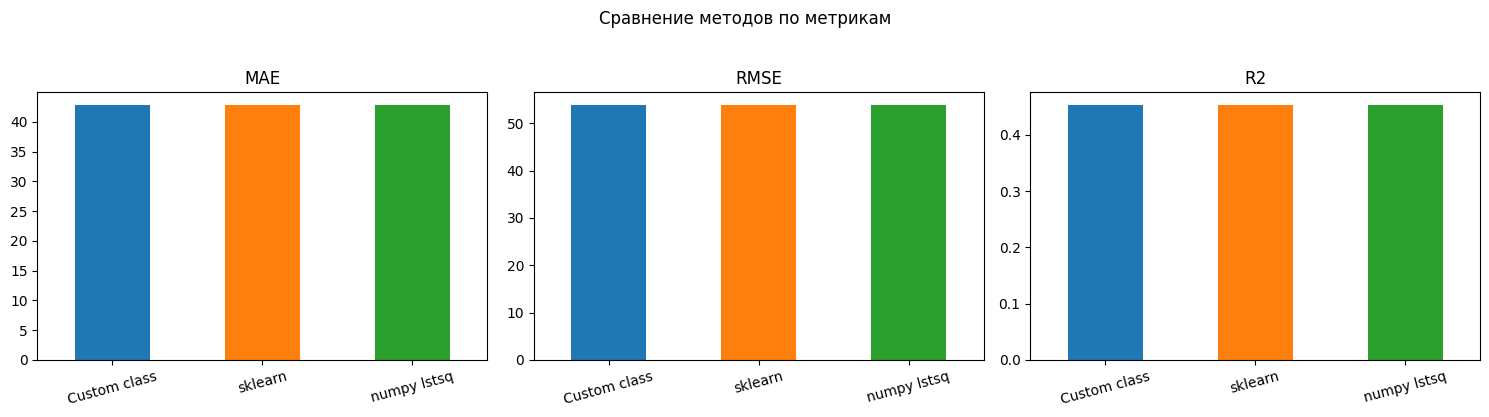

In [65]:
metrics = results.set_index("method")
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    metrics[metric].plot(kind="bar", ax=ax, color=colors)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Сравнение методов по метрикам", y=1.03)
plt.tight_layout()
plt.show()

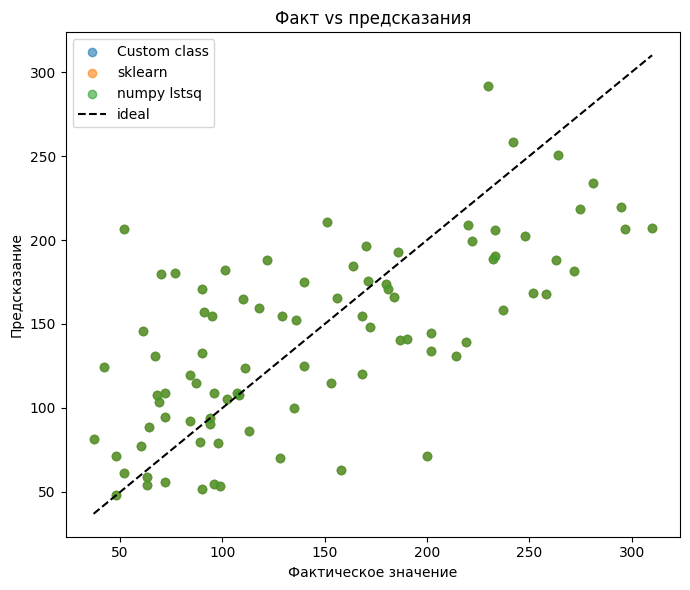

In [66]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, y_pred_custom, alpha=0.6, label="Custom class")
ax.scatter(y_test, y_pred_sk, alpha=0.6, label="sklearn")
ax.scatter(y_test, y_pred_lstsq, alpha=0.6, label="numpy lstsq")

min_v = float(min(y_test.min(), y_pred_custom.min(), y_pred_sk.min(), y_pred_lstsq.min()))
max_v = float(max(y_test.max(), y_pred_custom.max(), y_pred_sk.max(), y_pred_lstsq.max()))
ax.plot([min_v, max_v], [min_v, max_v], "k--", label="ideal")

ax.set_title("Факт vs предсказания")
ax.set_xlabel("Фактическое значение")
ax.set_ylabel("Предсказание")
ax.legend()
plt.tight_layout()
plt.show()

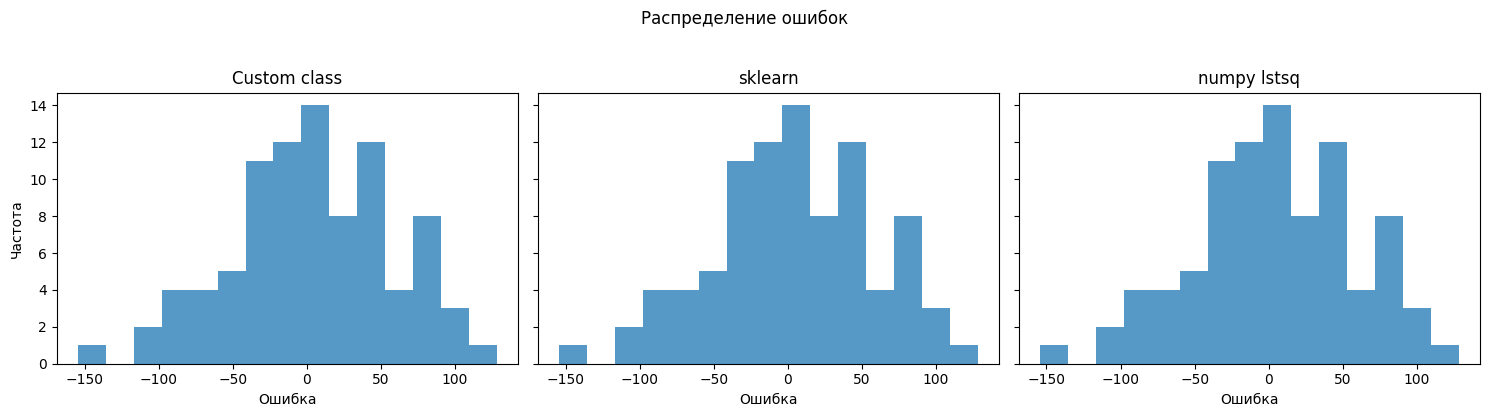

In [67]:
residuals = {
    "Custom class": y_test - y_pred_custom,
    "sklearn": y_test - y_pred_sk,
    "numpy lstsq": y_test - y_pred_lstsq,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, err) in zip(axes, residuals.items()):
    ax.hist(err, bins=15, alpha=0.75)
    ax.set_title(name)
    ax.set_xlabel("Ошибка")

axes[0].set_ylabel("Частота")
plt.suptitle("Распределение ошибок", y=1.03)
plt.tight_layout()
plt.show()

# Полиномиальная регрессия

In [68]:
degree_diabetes = 2

## Обучение

Мой класс

In [69]:
poly_custom_diabetes = PolynomialRegression(degree=degree_diabetes).fit(X_train, y_train)
y_pred_poly_custom_diabetes = poly_custom_diabetes.predict(X_test)

Sklearn

In [70]:
pf_diabetes = PolynomialFeatures(degree=degree_diabetes, include_bias=False)
X_train_poly_diabetes = pf_diabetes.fit_transform(X_train)
X_test_poly_diabetes = pf_diabetes.transform(X_test)
poly_sk_diabetes = SklearnLinearRegression().fit(X_train_poly_diabetes, y_train)
y_pred_poly_sk_diabetes = poly_sk_diabetes.predict(X_test_poly_diabetes)

In [71]:
diabetes_poly_results = pd.DataFrame([
    {
        "method": "Linear (custom)",
        "MAE": mae(y_test, y_pred_custom),
        "RMSE": rmse(y_test, y_pred_custom),
        "R2": r2(y_test, y_pred_custom),
    },
    {
        "method": "Polynomial d=2 (custom)",
        "MAE": mae(y_test, y_pred_poly_custom_diabetes),
        "RMSE": rmse(y_test, y_pred_poly_custom_diabetes),
        "R2": r2(y_test, y_pred_poly_custom_diabetes),
    },
    {
        "method": "Polynomial d=2 (sklearn)",
        "MAE": mae(y_test, y_pred_poly_sk_diabetes),
        "RMSE": rmse(y_test, y_pred_poly_sk_diabetes),
        "R2": r2(y_test, y_pred_poly_sk_diabetes),
    },
])

diabetes_poly_results

,method,MAE,RMSE,R2
0,Linear (custom),42.794095,53.853446,0.452603
1,Polynomial d=2 (custom),43.581693,55.641965,0.415640
2,Polynomial d=2 (sklearn),43.581693,55.641965,0.415640


## Сравнение

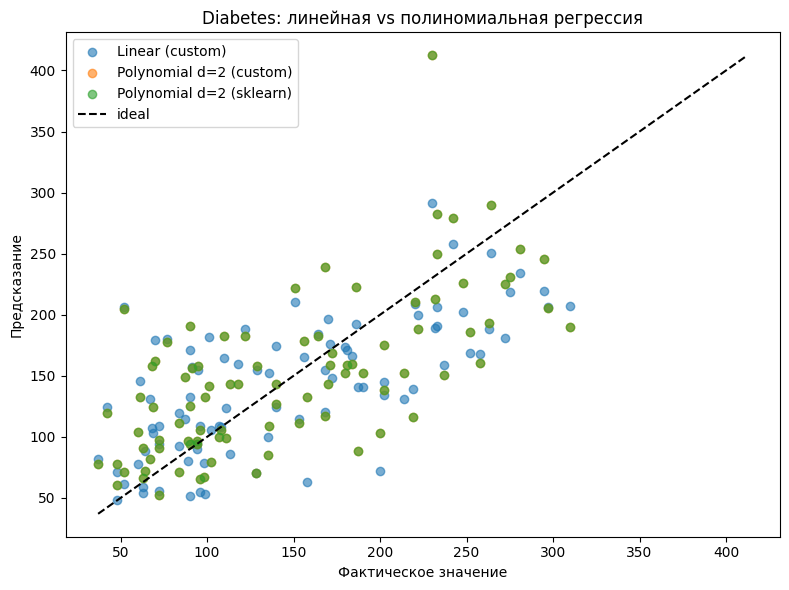

In [72]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_custom, alpha=0.6, label="Linear (custom)")
plt.scatter(y_test, y_pred_poly_custom_diabetes, alpha=0.6, label="Polynomial d=2 (custom)")
plt.scatter(y_test, y_pred_poly_sk_diabetes, alpha=0.6, label="Polynomial d=2 (sklearn)")

min_v = float(min(y_test.min(), y_pred_custom.min(), y_pred_poly_custom_diabetes.min(), y_pred_poly_sk_diabetes.min()))
max_v = float(max(y_test.max(), y_pred_custom.max(), y_pred_poly_custom_diabetes.max(), y_pred_poly_sk_diabetes.max()))
plt.plot([min_v, max_v], [min_v, max_v], "k--", label="ideal")

plt.title("Diabetes: линейная vs полиномиальная регрессия")
plt.xlabel("Фактическое значение")
plt.ylabel("Предсказание")
plt.legend()
plt.tight_layout()
plt.show()